In [1]:
# Part 2 final project

In [2]:
# Euler's Backward (Implicit Euler) method using Newton-Raphson iteration

In [29]:
# THIS SEGMENT OF CODE CAME STRAIGHT FROM SLACK, WHICH I ASSUME CAME FROM THE SLIDES.
# edited a little to track iteration count and do the explicit euler iteration guess.

# Newton-Raphson for single step with Backward Euler
print("hello")

hello


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters from problem
R = 100                  # ohms
C = 1e-9                 # farads
omega = 1                # rad/s

alpha = 1/(R*C)

# Source voltage
def V_source(t):
    return 5 * np.sin(omega * t)

# ODE: dV/dt
def f(t, V):
    return -alpha * V + alpha * V_source(t)

# Derivative of f
def fprime(V):
    return -alpha


# backward eueler code, based on slides
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y + h * f(t, y)  # good initial guess
    # y_next = y              # uncomment to test poor initial guess

    iter_count = 0

    for _ in range(max_iter):
        iter_count += 1

        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)

        if abs(g_prime_val) < tol:
            break

        y_new = y_next - g_val / g_prime_val

        if abs(y_new - y_next) < tol:
            return y_new, iter_count

        y_next = y_new

    return y_next, iter_count


# backward euler for later graphs, based from slides
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    iter_values = []

    h = h_init
    t = t0
    y = y0

    while t < tf:
        if t + h > tf:
            h = tf - t

        y_full, it1 = backward_euler_step(f, y, t, h, tol, max_iter)

        h_half = h / 2
        y_half_1, it2 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2, it3 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)

        error = abs(y_full - y_half_2)

        if error > tol:
            h /= 2
            continue
        elif error < tol / 2:
            h *= 2

        t += h
        y = y_half_2

        t_values.append(t)
        y_values.append(y)
        iter_values.append(it1 + it2 + it3)

    return np.array(t_values), np.array(y_values), np.array(iter_values)


# forward euler, frol slides
def forward_euler(f, y0, t0, tf, h):
    t_vals = [t0]
    y_vals = [y0]

    t = t0
    y = y0

    while t < tf:
        if t + h > tf:
            h = tf - t

        y = y + h * f(t, y)

        if not np.isfinite(y) or abs(y) > 1e6:
            break

        t += h
        t_vals.append(t)
        y_vals.append(y)

    return np.array(t_vals), np.array(y_vals)


# check if the values are stable
def is_stable(y_vals):
    if len(y_vals) == 0:
        return False
    if not np.all(np.isfinite(y_vals)):
        return False
    return np.max(np.abs(y_vals)) < 1e3




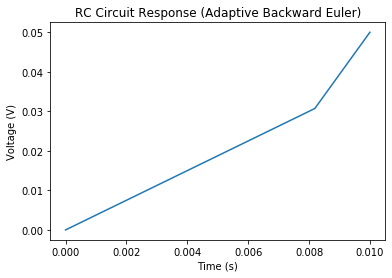

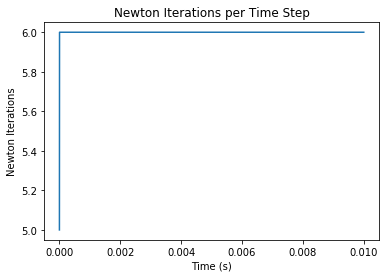

Step Size Comparison
h	Forward Euler	Backward Euler
1.0e-08	Stable		Stable
1.0e-07	Stable		Stable
5.0e-07	UNSTABLE		Stable
1.0e-06	UNSTABLE		Stable
5.0e-06	UNSTABLE		Stable
1.0e-05	UNSTABLE		Stable

Estimated Stability Ranges:
Forward Euler stable up to h ≈ 1e-07
Backward Euler stable up to h ≈ 1e-05


In [26]:
# initial values
t0 = 0
tf = 0.01
V0 = 0
h_init = 1e-6

# call backward euler and return to these variables
t_vals, V_vals, iter_vals = backward_euler_adaptive(f, V0, t0, tf, h_init)

# Plot solution
plt.figure()
plt.plot(t_vals, V_vals)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("RC Circuit Response (Adaptive Backward Euler)")
plt.show()

# Plot newton iterations
plt.figure()
plt.plot(t_vals[1:], iter_vals)
plt.xlabel("Time (s)")
plt.ylabel("Newton Iterations")
plt.title("Newton Iterations per Time Step")
plt.show()


# test different h values
h_values = [1e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5]

print("Step Size Comparison")
print("h\tForward Euler\tBackward Euler")

for h in h_values:
    t_f, y_f = forward_euler(f, V0, t0, tf, h)
    forward_status = "Stable" if is_stable(y_f) else "UNSTABLE"

    t_b, y_b, _ = backward_euler_adaptive(f, V0, t0, tf, h)
    backward_status = "Stable" if is_stable(y_b) else "UNSTABLE"

    print(f"{h:.1e}\t{forward_status}\t\t{backward_status}")


# step size summary
forward_stable_max = None
backward_stable_max = None

for h in h_values:
    t_f, y_f = forward_euler(f, V0, t0, tf, h)
    t_b, y_b, _ = backward_euler_adaptive(f, V0, t0, tf, h)

    if is_stable(y_f):
        forward_stable_max = h
    if is_stable(y_b):
        backward_stable_max = h

print("\nEstimated Stability Ranges:")
print(f"Forward Euler stable up to h ≈ {forward_stable_max}")
print(f"Backward Euler stable up to h ≈ {backward_stable_max}")





Accuracy vs Computational Cost (Backward Euler)
h	Steps	Avg Newton Iter	Func Evals
1.0e-08	20	5.11		194
1.0e-07	17	5.56		178
5.0e-07	15	5.86		164
1.0e-06	14	5.92		154
5.0e-06	11	5.90		118
1.0e-05	10	5.89		106

Forward Euler Cost (Stable Only)
h	Steps	Func Evals
1.0e-08	1000002	1000002
1.0e-07	100002	100002


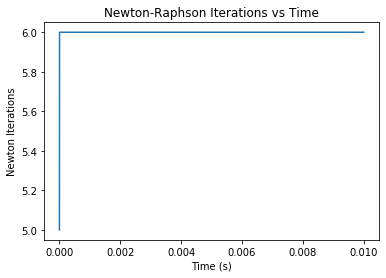

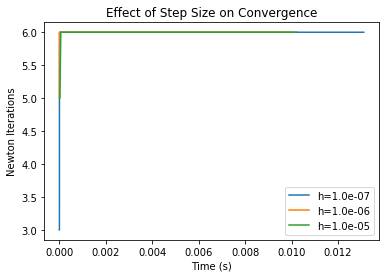

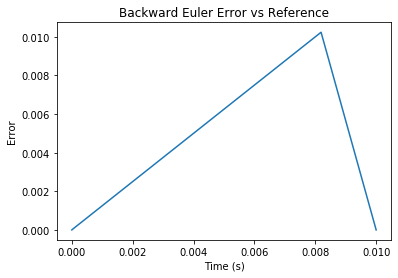

Solution remains within expected physical bounds


In [31]:
# ---------- Accuracy vs Cost ----------
print("\nAccuracy vs Computational Cost (Backward Euler)")
print("h\tSteps\tAvg Newton Iter\tFunc Evals")

for h in h_values:
    t_b, y_b, iter_b = backward_euler_adaptive(f, V0, t0, tf, h)

    steps = len(t_b)
    avg_iter = np.mean(iter_b) if len(iter_b) > 0 else 0
    func_evals = np.sum(iter_b) * 2

    print(f"{h:.1e}\t{steps}\t{avg_iter:.2f}\t\t{func_evals}")


# forward euler cost
print("\nForward Euler Cost (Stable Only)")
print("h\tSteps\tFunc Evals")

for h in h_values:
    t_f, y_f = forward_euler(f, V0, t0, tf, h)

    if is_stable(y_f):
        steps = len(t_f)
        func_evals = steps
        print(f"{h:.1e}\t{steps}\t{func_evals}")


# convergence behavior
plt.figure()
plt.plot(t_vals[1:], iter_vals)
plt.xlabel("Time (s)")
plt.ylabel("Newton Iterations")
plt.title("Newton-Raphson Iterations vs Time")
plt.show()


# step size 
plt.figure()

for h in [1e-7, 1e-6, 1e-5]:
    t_b, y_b, iter_b = backward_euler_adaptive(f, V0, t0, tf, h)
    plt.plot(t_b[1:], iter_b, label=f"h={h:.1e}")

plt.xlabel("Time (s)")
plt.ylabel("Newton Iterations")
plt.title("Effect of Step Size on Convergence")
plt.legend()
plt.show()


# refernce solution
t_ref, y_ref = forward_euler(f, V0, t0, tf, 1e-9)
y_ref_interp = np.interp(t_vals, t_ref, y_ref)

error = np.abs(V_vals - y_ref_interp)

plt.figure()
plt.plot(t_vals, error)
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("Backward Euler Error vs Reference")
plt.show()


# physical bounds check
if np.any(np.abs(V_vals) > 10):
    print("Warning: Solution may be leaving physical bounds")
else:
    print("Solution remains within expected physical bounds")


Testing initial guess...


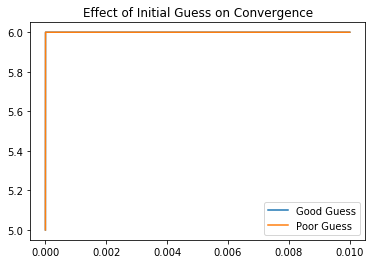

In [32]:
print("\nTesting initial guess...")

# temporarily switch guess in your function manually
# then rerun:
t_bad, y_bad, iter_bad = backward_euler_adaptive(f, V0, t0, tf, h_init)

plt.figure()
plt.plot(t_vals[1:], iter_vals, label="Good Guess")
plt.plot(t_bad[1:], iter_bad, label="Poor Guess")
plt.legend()
plt.title("Effect of Initial Guess on Convergence")
plt.show()